## Setup and Data Loading

## Setup and Data Loading

In [11]:
# Load required libraries (install 'did' if missing)
if (!requireNamespace('did', quietly = TRUE)) {
  install.packages('did', repos = 'https://cloud.r-project.org/')
  if (!requireNamespace('did', quietly = TRUE)) {
    if (!requireNamespace('remotes', quietly = TRUE)) install.packages('remotes', repos = 'https://cloud.r-project.org/')
    remotes::install_github('bcallaway11/did')
  }
}
library(tidyverse)
library(did)
library(fixest)
library(broom)
library(gridExtra)
library(scales)

# Set theme for plots
theme_set(theme_minimal(base_size = 14))

cat("Libraries loaded successfully!\n")

Libraries loaded successfully!


In [12]:
# Ensure 'did' package is installed via local install script if missing
if (!requireNamespace("did", quietly = TRUE)) {
  cat("'did' not found. Attempting to run install script ../install_packages.R\n")
  tryCatch({
    source("../install_packages.R")
  }, error = function(e) {
    cat(sprintf("Failed to source install script: %s\n", e$message))
  })
}
if (requireNamespace("did", quietly = TRUE)) {
  cat(sprintf("Package 'did' is available, version: %s\n", as.character(packageVersion("did"))))
} else {
  cat("Package 'did' is still not available after running installer.\n")
}

Package 'did' is available, version: 2.2.1.913


In [13]:
# Load the dataset from URL
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)

# Display basic information
cat("Dataset Shape:", nrow(df), "rows x", ncol(df), "columns\n")
cat("\nFirst few rows:\n")
head(df, 10)

Dataset Shape: 1617 rows x 10 columns

First few rows:

First few rows:


,stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156
2,1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186
3,1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219
4,1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250
5,1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283
6,1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316
7,1,1970,1971,0,44.23907,16222.95,4.716939,0.019703142,1715156,1787363
8,1,1971,1971,1,49.91467,16875.43,4.992504,0.022737451,1715156,1809412
9,1,1972,1971,1,47.20313,17976.76,5.187023,0.023555981,1715156,1831191


In [14]:
# Prepare data for CSDiD
# The did package needs:
# - gname: treatment cohort (0 for never-treated)
# - idname: unit identifier
# - tname: time identifier

df_csdid <- df %>%
  mutate(
    gvar = X_nfd,  # Treatment timing (0 = never treated)
    id = stfips,
    time = year
  )

# Verify the structure
cat("Treatment cohorts (gvar):\n")
print(sort(unique(df_csdid$gvar)))

cat("\nNumber of never-treated:", sum(df_csdid$gvar == 0) / length(unique(df_csdid$time)), "units\n")

Treatment cohorts (gvar):
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of never-treated: NA units
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of never-treated: NA units


---

## Part a) Estimate ATT(g,t) using CSDiD

In [15]:
# Estimate ATT(g,t) using Callaway-Sant'Anna
# Using doubly-robust estimation with controls

# Determine whether to use never-treated or notyettreated as control group
never_count <- df_csdid %>% filter(gvar == 0) %>% pull(stfips) %>% unique() %>% length()
control_choice <- ifelse(never_count >= 2, 'nevertreated', 'notyettreated')
cat(sprintf("Detected %d distinct never-treated units. Setting control_group = '%s'\n", never_count, control_choice))

# Note: Covariates removed due to small sample size in some groups causing "not implemented with more variables than observations" error
# Original formula: xformla = ~ pcinc + asmrh + cases
att_gt <- att_gt(
  yname = "asmrs",
  gname = "gvar",
  idname = "id",
  tname = "time",
  xformla = ~ 1, 
  data = df_csdid,
  est_method = "dr",  # Doubly-robust
  control_group = control_choice,
  anticipation = 0,
  base_period = "varying"
)

cat("========================================================================\n")
cat("ATT(g,t) ESTIMATION COMPLETE\n")
cat("========================================================================\n")
summary(att_gt)

Detected 0 distinct never-treated units. Setting control_group = 'notyettreated'


Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"dropped 429 rows from original data due to missing data"
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in att_gt(yname = "asmrs", gname = "gvar", idname = "id", tname = "time", :
"Not returning pre-test Wald statistic due to singular covariance matrix"
Warning message in att_gt(yname = "asmrs", gname = "gvar", idname = "id", tname = "time", :
"Not returning pre-test Wald statistic due to singular covariance matrix"
Warning message in att_gt(yname = "asmrs", gname = "gvar", idname = "id", tname = "time", :
"Simultane

ATT(g,t) ESTIMATION COMPLETE

Call:
att_gt(yname = "asmrs", tname = "time", idname = "id", gname = "gvar", 
    xformla = ~1, data = df_csdid, control_group = control_choice, 
    anticipation = 0, est_method = "dr", base_period = "varying")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
  1969 1965  -3.8814     6.2265     -353.3118    345.5490  
  1969 1966   5.5588     7.9369     -439.8594    450.9770  
  1969 1967   2.0449     5.3537     -298.4037    302.4935  
  1969 1968   3.0803     2.7673     -152.2197    158.3804  
  1969 1969   0.8709     5.6171     -314.3620    316.1037  
  1969 1970  -9.5746     8.7719     -501.8544    482.7052  
  1969 1971 -12.3828     7.4400     -429

In [16]:
# Create summary table of ATT(g,t)
att_gt_results <- data.frame(
  group = att_gt$group,
  time = att_gt$t,
  att = att_gt$att,
  se = att_gt$se,
  ci_lower = att_gt$att - 1.96 * att_gt$se,
  ci_upper = att_gt$att + 1.96 * att_gt$se
)

cat("\n========================================================================\n")
cat("ATT(g,t) RESULTS TABLE (First 20 entries)\n")
cat("========================================================================\n")
print(head(att_gt_results, 20))

cat(sprintf("\nTotal number of (g,t) cells: %d\n", nrow(att_gt_results)))


ATT(g,t) RESULTS TABLE (First 20 entries)
   group time          att         se   ci_lower    ci_upper
1   1969 1965  -3.88136207 6.22646951 -16.085242  8.32251817
2   1969 1966   5.55878432 7.93686715  -9.997475 21.11504394
3   1969 1967   2.04487733 5.35366732  -8.448311 12.53806529
4   1969 1968   3.08031811 2.76727758  -2.343546  8.50418218
5   1969 1969   0.87086184 5.61710650 -10.138667 11.88039058
6   1969 1970  -9.57458782 8.77189022 -26.767493  7.61831700
7   1969 1971 -12.38278687 7.44003477 -26.965255  2.19968128
8   1969 1972  -4.23193585 4.02191151 -12.114882  3.65101072
9   1969 1973   4.46408447 7.65200686 -10.533849 19.46201790
10  1969 1974   0.01875305 5.79840722 -11.346125 11.38363120
11  1969 1975   0.86218779 5.17280752  -9.276515 11.00089054
12  1969 1976 -13.26973979 8.03771096 -29.023653  2.48417370
13  1969 1977  -0.05026372 2.50966717  -4.969211  4.86868394
14  1969 1978  -5.36576207 7.33254084 -19.737542  9.00601797
15  1969 1979  -2.04050128 0.99482256  -3.

---

## Part b) Create Three Aggregations

### 1) Group-Time Aggregation (by Treatment Cohort)

In [17]:
# Aggregate by group (cohort)
agg_group <- aggte(att_gt, type = "group")

cat("========================================================================\n")
cat("GROUP-LEVEL AGGREGATION\n")
cat("========================================================================\n")
summary(agg_group)

Warning message in compute.aggte(MP = MP, type = type, balance_e = balance_e, min_e = min_e, :
"Simultaneous critical value is arguably `too large' to be realible. This usually happens when number of observations per group is small and/or there is no much variation in outcomes."


GROUP-LEVEL AGGREGATION

Call:
aggte(MP = att_gt, type = "group")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on group/cohort aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 1.3553        3.4541    -5.4146      8.1251 


Group Effects:
 Group Estimate Std. Error [95% Simult.   Conf. Band] 
  1969  -3.2769     7.1015 -2.723381e+16 2.723381e+16 
  1970 -17.0455     9.1966 -3.526853e+16 3.526853e+16 
  1971   1.6685     4.4672 -1.713155e+16 1.713155e+16 
  1972   2.7390     6.2998 -2.415927e+16 2.415927e+16 
  1973  11.8298     6.1447 -2.356447e+16 2.356447e+16 
  1974  -6.8765     4.0634 -1.558310e+16 1.558310e+16 
  1975  -3.4593     3.2741 -1.255597e+16 1.255597e+16 
  1976  -2.4307     1.5173 -5.818888e+15 5.818888e+15 
  1977 

In [18]:
# Extract group aggregation results
group_results <- data.frame(
  group = agg_group$egt,
  att = agg_group$att.egt,
  se = agg_group$se.egt
) %>%
  mutate(
    ci_lower = att - 1.96 * se,
    ci_upper = att + 1.96 * se
  )

cat("\nGroup-level ATT estimates:\n")
print(group_results)
cat(sprintf("\nOverall ATT: %.4f (SE: %.4f)\n", agg_group$overall.att, agg_group$overall.se))


Group-level ATT estimates:
   group        att       se   ci_lower   ci_upper
1   1969  -3.276924 7.101488 -17.195840 10.6419926
2   1970 -17.045527 9.196621 -35.070905  0.9798504
3   1971   1.668459 4.467223  -7.087298 10.4242164
4   1972   2.738983 6.299770  -9.608566 15.0865327
5   1973  11.829834 6.144669  -0.213718 23.8733863
6   1974  -6.876458 4.063449 -14.840817  1.0879016
7   1975  -3.459287 3.274095  -9.876513  2.9579400
8   1976  -2.430675 1.517333  -5.404647  0.5432983
9   1977  -4.666900 8.125208 -20.592307 11.2585079
10  1980  -8.656535       NA         NA         NA
11  1984   2.520073       NA         NA         NA

Overall ATT: 1.3553 (SE: 3.4541)
   group        att       se   ci_lower   ci_upper
1   1969  -3.276924 7.101488 -17.195840 10.6419926
2   1970 -17.045527 9.196621 -35.070905  0.9798504
3   1971   1.668459 4.467223  -7.087298 10.4242164
4   1972   2.738983 6.299770  -9.608566 15.0865327
5   1973  11.829834 6.144669  -0.213718 23.8733863
6   1974  -6.876458 

### 2) Calendar Time Aggregation

In [19]:
# Aggregate by calendar time
agg_calendar <- aggte(att_gt, type = "calendar")

cat("========================================================================\n")
cat("CALENDAR TIME AGGREGATION\n")
cat("========================================================================\n")
summary(agg_calendar)

CALENDAR TIME AGGREGATION

Call:
aggte(MP = att_gt, type = "calendar")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on calendar time aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.5594        2.9922    -5.3053       6.424 


Time Effects:
 Time Estimate Std. Error [95% Simult.  Conf. Band] 
 1969   0.8709     5.4186      -12.4396     14.1814 
 1970  -4.9186     6.1617      -20.0543     10.2171 
 1971  -7.4450     4.6152      -18.7819      3.8920 
 1972  -7.1945     4.6374      -18.5859      4.1969 
 1973   4.5117     4.9393       -7.6214     16.6448 
 1974   4.7292     4.9902       -7.5289     16.9872 
 1975   8.6461     4.7351       -2.9853     20.2776 
 1976   3.1583     9.0027      -18.9562     25.2729 
 1977   6.7518     6

In [20]:
# Extract calendar time results
calendar_results <- data.frame(
  year = agg_calendar$egt,
  att = agg_calendar$att.egt,
  se = agg_calendar$se.egt
) %>%
  mutate(
    ci_lower = att - 1.96 * se,
    ci_upper = att + 1.96 * se
  )

cat("\nCalendar time ATT estimates:\n")
print(calendar_results)


Calendar time ATT estimates:
   year        att       se    ci_lower   ci_upper
1  1969  0.8708618 5.418626  -9.7496444 11.4913681
2  1970 -4.9186387 6.161656 -16.9954836  7.1582062
3  1971 -7.4449726 4.615208 -16.4907795  1.6008343
4  1972 -7.1945010 4.637366 -16.2837385  1.8947366
5  1973  4.5116921 4.939303  -5.1693423 14.1927265
6  1974  4.7291866 4.990182  -5.0515694 14.5099426
7  1975  8.6461465 4.735098  -0.6346457 17.9269387
8  1976  3.1583291 9.002714 -14.4869904 20.8036486
9  1977  6.7518090 6.661669  -6.3050625 19.8086806
10 1978 -2.7159050 3.179750  -8.9482155  3.5164055
11 1979  1.8886907 5.424648  -8.7436200 12.5210013
12 1980 -1.0344283 3.141640  -7.1920435  5.1231868
13 1981  4.4693855 6.014969  -7.3199541 16.2587252
14 1982 -5.1739713 3.019575 -11.0923389  0.7443963
15 1983 -1.4180145 5.565286 -12.3259752  9.4899462
16 1984  3.8242876 3.725189  -3.4770835 11.1256588
   year        att       se    ci_lower   ci_upper
1  1969  0.8708618 5.418626  -9.7496444 11.4913681
2

### 3) Dynamic (Event-Time) Aggregation

In [21]:
# Aggregate by event time (dynamic effects)
agg_dynamic <- aggte(att_gt, type = "dynamic")

cat("========================================================================\n")
cat("DYNAMIC (EVENT-TIME) AGGREGATION\n")
cat("========================================================================\n")
summary(agg_dynamic)

DYNAMIC (EVENT-TIME) AGGREGATION

Call:
aggte(MP = att_gt, type = "dynamic")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.1073        3.3135    -6.3871      6.6017 


Dynamic Effects:
 Event time Estimate Std. Error [95% Simult.  Conf. Band] 
        -19   1.9132     2.1039       -3.8741      7.7004 
        -18   0.2689     2.2542       -5.9319      6.4697 
        -17  -2.7782     2.4281       -9.4573      3.9009 
        -16  -2.3641     2.2396       -8.5246      3.7964 
        -15  -2.6024     3.1571      -11.2867      6.0819 
        -14   1.6679     1.7670       -3.1925      6.5283 
        -13  -5.7314     4.3689      -17.7490      6.2862 
        -1

In [22]:
# Extract dynamic results
dynamic_results <- data.frame(
  event_time = agg_dynamic$egt,
  att = agg_dynamic$att.egt,
  se = agg_dynamic$se.egt
) %>%
  mutate(
    ci_lower = att - 1.96 * se,
    ci_upper = att + 1.96 * se
  )

cat("\nDynamic ATT estimates:\n")
print(dynamic_results)


Dynamic ATT estimates:
   event_time         att        se    ci_lower   ci_upper
1         -19   1.9131519  2.103894  -2.2104806  6.0367845
2         -18   0.2688974  2.254232  -4.1493979  4.6871927
3         -17  -2.7781966  2.428126  -7.5373236  1.9809304
4         -16  -2.3640792  2.239598  -6.7536920  2.0255337
5         -15  -2.6023732  3.157097  -8.7902841  3.5855376
6         -14   1.6679274  1.766959  -1.7953120  5.1311668
7         -13  -5.7314185  4.368875 -14.2944144  2.8315773
8         -12   6.1681238  4.522761  -2.6964882 15.0327358
9         -11  -9.6671449  5.419899 -20.2901473  0.9558576
10        -10   9.0972067  6.385452  -3.4182793 21.6126928
11         -9  -7.4354999  4.796534 -16.8367068  1.9657070
12         -8   3.3430454  2.714456  -1.9772893  8.6633800
13         -7   0.3180943  2.134616  -3.8657524  4.5019411
14         -6  -1.2394527  3.245221  -7.6000857  5.1211803
15         -5  -2.1888093  2.339465  -6.7741601  2.3965415
16         -4   3.3185045  1.916

---

## Part c) Visualizations

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


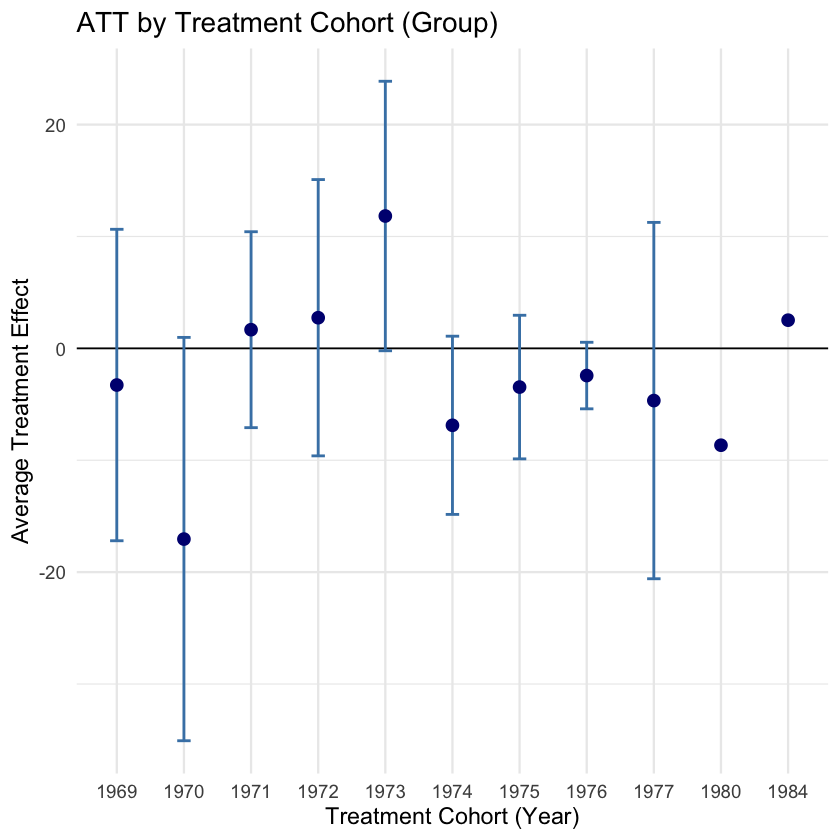

In [23]:
# Plot 1: Group-level ATT
p1 <- ggplot(group_results, aes(x = factor(group), y = att)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.2, color = "steelblue", size = 0.8) +
  geom_point(color = "navy", size = 3) +
  labs(
    title = "ATT by Treatment Cohort (Group)",
    x = "Treatment Cohort (Year)",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(p1)
ggsave("../output/csdid_group_agg.png", p1, width = 10, height = 6, dpi = 300)

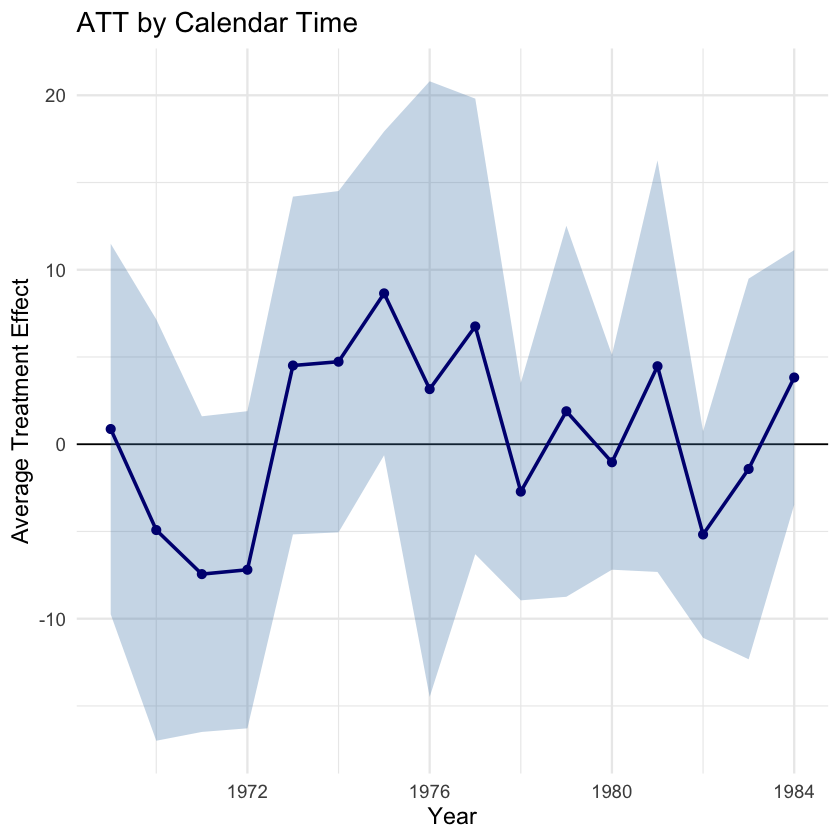

In [24]:
# Plot 2: Calendar Time ATT
p2 <- ggplot(calendar_results, aes(x = year, y = att)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper), fill = "steelblue", alpha = 0.3) +
  geom_line(color = "navy", size = 1) +
  geom_point(color = "navy", size = 2) +
  labs(
    title = "ATT by Calendar Time",
    x = "Year",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(p2)
ggsave("../output/csdid_calendar_agg.png", p2, width = 10, height = 6, dpi = 300)

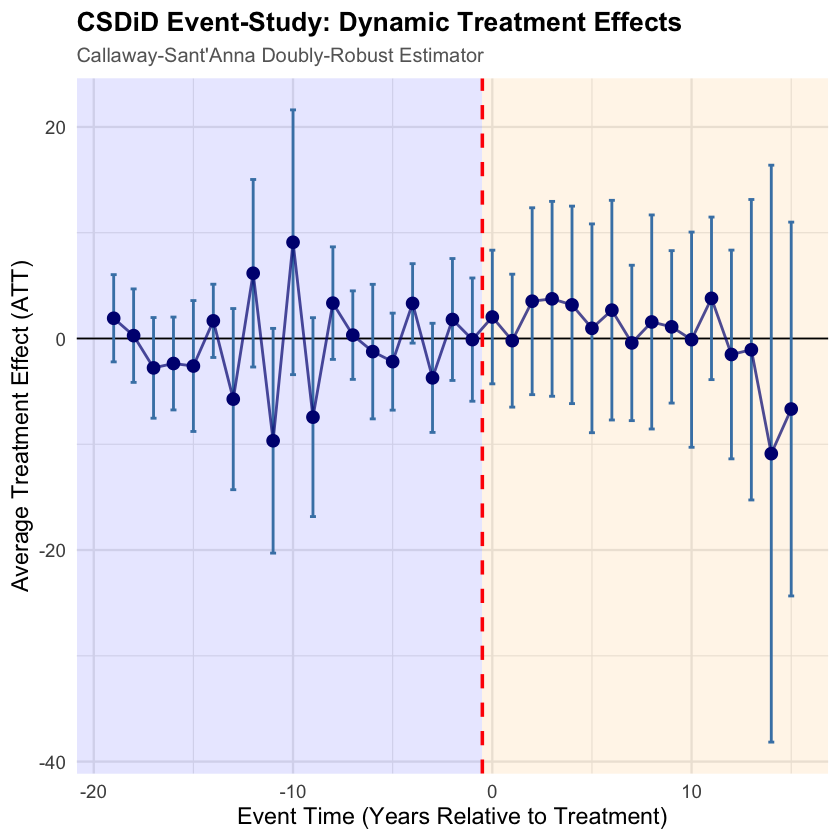

In [25]:
# Plot 3: Dynamic Event-Study
p3 <- ggplot(dynamic_results, aes(x = event_time, y = att)) +
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "blue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, 
           fill = "orange", alpha = 0.1) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.3, color = "steelblue", size = 0.8) +
  geom_line(color = "navy", alpha = 0.7, size = 0.8) +
  geom_point(color = "navy", size = 3) +
  labs(
    title = "CSDiD Event-Study: Dynamic Treatment Effects",
    subtitle = "Callaway-Sant'Anna Doubly-Robust Estimator",
    x = "Event Time (Years Relative to Treatment)",
    y = "Average Treatment Effect (ATT)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray40")
  )

print(p3)
ggsave("../output/csdid_dynamic_agg.png", p3, width = 14, height = 8, dpi = 300)

---

## Comparison: CSDiD vs TWFE

In [26]:
# Get TWFE estimate for comparison
df$treated_post <- df$post * df$X_treated

twfe_model <- feols(
  asmrs ~ treated_post + pcinc + asmrh + cases | stfips + year,
  data = df,
  cluster = ~stfips
)

twfe_coef <- coef(twfe_model)["treated_post"]
twfe_se <- sqrt(vcov(twfe_model)["treated_post", "treated_post"])

# CSDiD overall
csdid_coef <- agg_dynamic$overall.att
csdid_se <- agg_dynamic$overall.se

cat("========================================================================\n")
cat("COMPARISON: TWFE vs CSDiD\n")
cat("========================================================================\n")
cat(sprintf("TWFE Estimate:  %.4f (SE: %.4f)\n", twfe_coef, twfe_se))
cat(sprintf("CSDiD Estimate: %.4f (SE: %.4f)\n", csdid_coef, csdid_se))
cat(sprintf("\nDifference: %.4f\n", twfe_coef - csdid_coef))

ERROR: Error in `$<-.data.frame`(`*tmp*`, treated_post, value = integer(0)): replacement has 0 rows, data has 1617


In [ ]:
# Comparison plot
comparison_df <- data.frame(
  Method = c("TWFE", "CSDiD"),
  Estimate = c(twfe_coef, csdid_coef),
  SE = c(twfe_se, csdid_se)
) %>%
  mutate(
    ci_lower = Estimate - 1.96 * SE,
    ci_upper = Estimate + 1.96 * SE
  )

p_comp <- ggplot(comparison_df, aes(x = Method, y = Estimate, fill = Method)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_bar(stat = "identity", width = 0.5, alpha = 0.8) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.2, size = 0.8) +
  scale_fill_manual(values = c("#E74C3C", "#3498DB")) +
  labs(
    title = "Treatment Effect Comparison: TWFE vs CSDiD",
    subtitle = "95% Confidence Intervals",
    y = "Estimated Treatment Effect",
    x = ""
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

print(p_comp)
ggsave("../output/twfe_vs_csdid_comparison.png", p_comp, width = 8, height = 6, dpi = 300)

In [ ]:
# Get TWFE event study for comparison
LOWER_BOUND <- -10
UPPER_BOUND <- 10

df_es <- df %>%
  filter(X_nfd > 0) %>%
  mutate(
    event_time = year - X_nfd,
    event_time_binned = pmin(pmax(event_time, LOWER_BOUND), UPPER_BOUND),
    event_time_factor = factor(event_time_binned),
    event_time_factor = relevel(event_time_factor, ref = "-1")
  )

twfe_es <- feols(
  asmrs ~ event_time_factor + pcinc + asmrh + cases | stfips + year,
  data = df_es,
  cluster = ~stfips
)

twfe_es_results <- tidy(twfe_es, conf.int = TRUE) %>%
  filter(str_detect(term, "event_time_factor")) %>%
  mutate(
    event_time = as.numeric(str_extract(term, "-?\\d+")),
    method = "TWFE"
  ) %>%
  select(event_time, estimate, conf.low, conf.high, method)

# Add reference
twfe_es_results <- bind_rows(
  twfe_es_results,
  tibble(event_time = -1, estimate = 0, conf.low = 0, conf.high = 0, method = "TWFE")
)

# CSDiD dynamic results
csdid_es_results <- dynamic_results %>%
  mutate(method = "CSDiD") %>%
  rename(estimate = att, conf.low = ci_lower, conf.high = ci_upper)

# Combine
combined_es <- bind_rows(twfe_es_results, csdid_es_results)

In [ ]:
# Combined Event-Study Plot
p_combined <- ggplot(combined_es, aes(x = event_time, y = estimate, color = method)) +
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "gray", alpha = 0.15) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1) +
  geom_line(size = 1, alpha = 0.8) +
  geom_point(size = 3) +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, fill = method), 
              alpha = 0.2, color = NA) +
  scale_color_manual(values = c("CSDiD" = "#3498DB", "TWFE" = "#E74C3C")) +
  scale_fill_manual(values = c("CSDiD" = "#3498DB", "TWFE" = "#E74C3C")) +
  labs(
    title = "Event-Study Comparison: TWFE vs CSDiD",
    subtitle = "Shaded regions show 95% confidence intervals",
    x = "Event Time (Years Relative to Treatment)",
    y = "Estimated Effect on ASMRS",
    color = "Method",
    fill = "Method"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    legend.position = "bottom"
  )

print(p_combined)
ggsave("../output/combined_event_study_comparison.png", p_combined, 
       width = 14, height = 8, dpi = 300)

---

## Summary

In [ ]:
# Save all results
write.csv(att_gt_results, "../output/att_gt_results.csv", row.names = FALSE)
write.csv(group_results, "../output/group_aggregation.csv", row.names = FALSE)
write.csv(calendar_results, "../output/calendar_aggregation.csv", row.names = FALSE)
write.csv(dynamic_results, "../output/dynamic_aggregation.csv", row.names = FALSE)

cat("All results saved to ../output/\n")

In [ ]:
# Final summary
cat("========================================================================\n")
cat("SUMMARY OF QUESTION 2 RESULTS (R)\n")
cat("========================================================================\n")

cat("\n1. ATT(g,t) Estimation:")
cat(sprintf("\n   - Total (g,t) cells: %d", nrow(att_gt_results)))
cat(sprintf("\n   - Treatment cohorts: %s", paste(unique(att_gt_results$group), collapse = ", ")))

cat("\n\n2. Aggregations:")
cat(sprintf("\n   - Group ATT (overall): %.4f (SE: %.4f)", agg_group$overall.att, agg_group$overall.se))
cat(sprintf("\n   - Dynamic ATT (overall): %.4f (SE: %.4f)", agg_dynamic$overall.att, agg_dynamic$overall.se))

cat("\n\n3. TWFE vs CSDiD Comparison:")
cat(sprintf("\n   - TWFE: %.4f", twfe_coef))
cat(sprintf("\n   - CSDiD: %.4f", csdid_coef))
cat(sprintf("\n   - Difference: %.4f", twfe_coef - csdid_coef))

cat("\n\n4. Output files generated:")
cat("\n   - csdid_group_agg.png")
cat("\n   - csdid_calendar_agg.png")
cat("\n   - csdid_dynamic_agg.png")
cat("\n   - twfe_vs_csdid_comparison.png")
cat("\n   - combined_event_study_comparison.png")
cat("\n   - att_gt_results.csv")
cat("\n   - group_aggregation.csv")
cat("\n   - calendar_aggregation.csv")
cat("\n   - dynamic_aggregation.csv\n")

## Setup and Data Loading

In [ ]:
# Load required libraries (install 'did' if missing)
if (!requireNamespace('did', quietly = TRUE)) {
  install.packages('did', repos = 'https://cloud.r-project.org/')
  if (!requireNamespace('did', quietly = TRUE)) {
    if (!requireNamespace('remotes', quietly = TRUE)) install.packages('remotes', repos = 'https://cloud.r-project.org/')
    remotes::install_github('bcallaway11/did')
  }
}
library(tidyverse)
library(did)
library(broom)
library(knitr)
library(kableExtra)
library(gridExtra)
library(scales)

# Set theme for plots
theme_set(theme_minimal(base_size = 14))

cat("Libraries loaded successfully!\n")

In [ ]:
# Load the dataset
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)

cat("Dataset loaded successfully!\n")
cat("Shape:", nrow(df), "rows x", ncol(df), "columns\n")
head(df)

In [ ]:
# Prepare data for CSDiD
# The did package requires:
# - yname: outcome variable
# - tname: time variable  
# - idname: unit identifier
# - gname: group variable (first treatment period, 0 for never-treated)

cat("Treatment groups (first treatment period):\n")
table(df$X_nfd)

cat("\nNote: X_nfd = 0 indicates never-treated units\n")

In [ ]:
# Create clean copy for CSDiD
df_csdid <- df

cat("\nData summary for CSDiD:\n")
cat("  Outcome variable (asmrs): mean =", round(mean(df_csdid$asmrs), 2), "\n")
cat("  Unit identifier (stfips):", length(unique(df_csdid$stfips)), "unique units\n")
cat("  Time variable (year):", min(df_csdid$year), "to", max(df_csdid$year), "\n")
cat("  Group variable (X_nfd):", length(unique(df_csdid$X_nfd)), "treatment cohorts\n")

---

## Part a) CSDiD Estimation: ATT(g,t)

The Callaway and Sant'Anna (2021) estimator computes group-time average treatment effects:

$$ATT(g,t) = E[Y_t(1) - Y_t(0) | G_g = 1]$$

Where:
- $g$ = treatment cohort (first treatment period)
- $t$ = calendar time period
- $G_g = 1$ indicates units first treated in period $g$

In [ ]:
# Estimate ATT(g,t) using the did package
# Including pcinc, asmrh, and cases as control variables

# Determine whether to use 'nevertreated' or 'notyettreated' as the control group
never_count <- df_csdid %>% filter(X_nfd == 0) %>% pull(stfips) %>% unique() %>% length()
control_choice <- ifelse(never_count >= 2, 'nevertreated', 'notyettreated')
cat(sprintf("Detected %d distinct never-treated units. Setting control_group = '%s'\n", never_count, control_choice))
att_gt_results <- att_gt(
  yname = "asmrs",           # Outcome variable
  tname = "year",            # Time variable
  idname = "stfips",         # Unit identifier
  gname = "X_nfd",           # Group (first treatment period)
  xformla = ~ pcinc + asmrh + cases,  # Control variables
  data = df_csdid,
  control_group = control_choice,  # Selected control group (auto-determined)
  est_method = "dr",         # Doubly robust estimation
  print_details = FALSE
)

cat("CSDiD estimation completed!\n")
cat("\nNumber of ATT(g,t) estimates:", length(att_gt_results$att), "\n")

In [ ]:
# Summary of ATT(g,t) results
summary(att_gt_results)

In [ ]:
# Create clean table of ATT(g,t) results
att_gt_df <- data.frame(
  Group = att_gt_results$group,
  Time = att_gt_results$t,
  ATT = att_gt_results$att,
  SE = att_gt_results$se,
  CI_Lower = att_gt_results$att - 1.96 * att_gt_results$se,
  CI_Upper = att_gt_results$att + 1.96 * att_gt_results$se
) %>%
  mutate(
    Significant = ifelse((CI_Lower > 0) | (CI_Upper < 0), "***", "")
  )

cat("========================================================================\n")
cat("ATT(g,t) ESTIMATES - CALLAWAY-SANT'ANNA DIFFERENCE-IN-DIFFERENCES\n")
cat("========================================================================\n")
print(att_gt_df)

In [ ]:
# Create pivot table for visualization
att_pivot <- att_gt_df %>%
  select(Group, Time, ATT) %>%
  pivot_wider(names_from = Time, values_from = ATT, names_prefix = "t_")

cat("\n========================================================================\n")
cat("ATT(g,t) PIVOT TABLE\n")
cat("Rows: Treatment Cohort (g) | Columns: Calendar Time (t)\n")
cat("========================================================================\n")
print(att_pivot)

# Save to CSV
write.csv(att_gt_df, "../output/att_gt_results.csv", row.names = FALSE)
cat("\nResults saved to: ../output/att_gt_results.csv\n")

In [ ]:
# Visualize ATT(g,t) using the built-in plot function
png("../output/att_gt_plot.png", width = 1400, height = 800, res = 150)
ggdid(att_gt_results)
dev.off()

# Display in notebook
ggdid(att_gt_results)

cat("\nFigure saved to: ../output/att_gt_plot.png")

---

## Part b) Aggregations

CSDiD provides three main aggregation methods to summarize group-time effects.

### b.1) Aggregation by Group

Aggregates ATT(g,t) across all post-treatment periods for each treatment cohort:

$$ATT_{group}(g) = \frac{1}{|\{t: t \geq g\}|} \sum_{t \geq g} ATT(g,t)$$

In [ ]:
# Aggregation by Group
agg_group <- aggte(att_gt_results, type = "group")

cat("========================================================================\n")
cat("AGGREGATION BY GROUP\n")
cat("Average treatment effect for each treatment cohort\n")
cat("========================================================================\n")
summary(agg_group)

In [ ]:
# Extract group-level results
agg_group_df <- data.frame(
  Group = agg_group$egt,
  ATT = agg_group$att.egt,
  SE = agg_group$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  )

print(agg_group_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_group$overall.att, agg_group$overall.se))

In [ ]:
# Plot aggregation by group
group_plot <- ggplot(agg_group_df, aes(x = factor(Group), y = ATT)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_hline(yintercept = agg_group$overall.att, color = "red", 
             linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.2, color = "darkgreen", size = 0.8) +
  geom_point(color = "darkgreen", size = 4) +
  labs(
    title = "CSDiD: Aggregation by Group",
    subtitle = paste0("Overall ATT = ", round(agg_group$overall.att, 2)),
    x = "Treatment Cohort (First Treatment Year)",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(group_plot)

ggsave("../output/csdid_aggregation_group.png", group_plot, 
       width = 10, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/csdid_aggregation_group.png")

### b.2) Aggregation by Period (Calendar Time)

Aggregates ATT(g,t) across all treated groups for each calendar period:

$$ATT_{calendar}(t) = \sum_{g \leq t} w_g \cdot ATT(g,t)$$

In [ ]:
# Aggregation by Calendar Time
agg_time <- aggte(att_gt_results, type = "calendar")

cat("========================================================================\n")
cat("AGGREGATION BY CALENDAR TIME (PERIOD)\n")
cat("Average treatment effect for each calendar period\n")
cat("========================================================================\n")
summary(agg_time)

In [ ]:
# Extract calendar-level results
agg_time_df <- data.frame(
  Time = agg_time$egt,
  ATT = agg_time$att.egt,
  SE = agg_time$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  )

print(agg_time_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_time$overall.att, agg_time$overall.se))

In [ ]:
# Plot aggregation by time
time_plot <- ggplot(agg_time_df, aes(x = Time, y = ATT)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_hline(yintercept = agg_time$overall.att, color = "red", 
             linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.3, color = "darkblue", size = 0.8) +
  geom_line(color = "darkblue", alpha = 0.7, size = 0.8) +
  geom_point(color = "darkblue", size = 3, shape = 15) +
  labs(
    title = "CSDiD: Aggregation by Calendar Time",
    subtitle = paste0("Overall ATT = ", round(agg_time$overall.att, 2)),
    x = "Calendar Year",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(time_plot)

ggsave("../output/csdid_aggregation_calendar.png", time_plot, 
       width = 12, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/csdid_aggregation_calendar.png")

### b.3) Aggregation by Event-Time (Dynamic Effects)

Aggregates ATT(g,t) across all groups for each event-time:

$$ATT_{event}(e) = \sum_{g} w_g \cdot ATT(g, g+e)$$

Where $e = t - g$ is the event time (years since treatment).

In [ ]:
# Aggregation by Event Time (Dynamic Effects)
agg_event <- aggte(att_gt_results, type = "dynamic")

cat("========================================================================\n")
cat("AGGREGATION BY EVENT-TIME (DYNAMIC EFFECTS)\n")
cat("Average treatment effect at each relative time since treatment\n")
cat("========================================================================\n")
summary(agg_event)

In [ ]:
# Extract event-time results
agg_event_df <- data.frame(
  Event_Time = agg_event$egt,
  ATT = agg_event$att.egt,
  SE = agg_event$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  ) %>%
  arrange(Event_Time)

print(agg_event_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_event$overall.att, agg_event$overall.se))

# Save event-time aggregation
write.csv(agg_event_df, "../output/csdid_event_time.csv", row.names = FALSE)
cat("\nEvent-time results saved to: ../output/csdid_event_time.csv")

In [ ]:
# Plot dynamic effects
event_plot <- ggplot(agg_event_df, aes(x = Event_Time, y = ATT)) +
  # Shading
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "blue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, 
           fill = "orange", alpha = 0.1) +
  # Reference lines
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "blue", linetype = "dashed", size = 1) +
  # Data
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.3, color = "indianred", size = 0.8) +
  geom_line(color = "darkred", alpha = 0.7, size = 0.8) +
  geom_point(color = "darkred", size = 3) +
  # Labels
  labs(
    title = "CSDiD: Dynamic Effects (Event-Time Aggregation)",
    subtitle = "Callaway-Sant'Anna Difference-in-Differences",
    x = "Event Time (Years Since Treatment)",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(event_plot)

ggsave("../output/csdid_event_study.png", event_plot, 
       width = 14, height = 8, dpi = 300)
cat("\nFigure saved to: ../output/csdid_event_study.png")

---

## Part c) Explanation of Aggregations

### c.1) Aggregation by Group

**Meaning:** The group-specific ATT gives the average treatment effect for units in a particular treatment cohort, averaged across all post-treatment periods.

**Interpretation:** Shows whether treatment had different effects on different cohorts (e.g., early vs. late adopters).

**Use case:** Understanding heterogeneity across treatment cohorts.

---

### c.2) Aggregation by Period

**Meaning:** The calendar-time ATT gives the average treatment effect in a specific calendar year, weighted by cohort shares.

**Interpretation:** Shows how treatment effect evolved over calendar time.

**Use case:** Policy evaluation at specific points in time.

---

### c.3) Aggregation by Event-Time

**Meaning:** The event-time ATT gives the average treatment effect at specific periods relative to treatment.

**Interpretation:** Analogous to traditional event-study, showing:
- Pre-trends (event time < 0)
- Impact effects (event time = 0)
- Dynamic effects (event time > 0)

**Use case:** Understanding dynamics of treatment effects.

---

### c.4) Which aggregation is most comparable to TWFE Event-Study?

**Answer: Event-Time Aggregation**

The event-time aggregation is most comparable because:
1. Both measure effects at specific periods relative to treatment
2. Both show dynamic patterns of treatment effects
3. Reference period is normalized similarly

**Key difference:** CSDiD uses only clean comparisons, while TWFE may use already-treated units as controls.

---

## Part d) Comparison: CSDiD vs TWFE Event-Study

In [ ]:
# Load TWFE event-study results from Question 1
twfe_file <- "../output/event_study_coefficients.csv"

if (file.exists(twfe_file)) {
  twfe_es_df <- read.csv(twfe_file)
  cat("TWFE Event-Study results loaded successfully!\n")
  head(twfe_es_df)
} else {
  cat("Note: TWFE results not found. Please run Q1 notebook first.\n")
  twfe_es_df <- NULL
}

In [ ]:
# Create comparison table
if (!is.null(twfe_es_df)) {
  # Prepare CSDiD data
  csdid_compare <- agg_event_df %>%
    select(Event_Time, ATT, SE) %>%
    rename(
      event_time = Event_Time,
      CSDiD_ATT = ATT,
      CSDiD_SE = SE
    )
  
  # Prepare TWFE data
  twfe_compare <- twfe_es_df %>%
    select(event_time, coefficient, std_error) %>%
    rename(
      TWFE_Coef = coefficient,
      TWFE_SE = std_error
    )
  
  # Merge
  comparison_df <- full_join(csdid_compare, twfe_compare, by = "event_time") %>%
    arrange(event_time) %>%
    mutate(
      Difference = CSDiD_ATT - TWFE_Coef
    )
  
  cat("========================================================================\n")
  cat("COMPARISON TABLE: CSDiD vs TWFE EVENT-STUDY\n")
  cat("========================================================================\n")
  print(comparison_df)
  
  # Save comparison table
  write.csv(comparison_df, "../output/comparison_csdid_twfe.csv", row.names = FALSE)
  cat("\nComparison table saved to: ../output/comparison_csdid_twfe.csv\n")
} else {
  cat("Cannot create comparison - TWFE results not available.\n")
}

In [ ]:
# Create combined comparison plot
if (!is.null(twfe_es_df)) {
  
  # Prepare data for plotting
  plot_data <- bind_rows(
    agg_event_df %>%
      mutate(Method = "CSDiD", event_time = Event_Time) %>%
      select(event_time, ATT, SE = SE, CI_Lower, CI_Upper, Method),
    twfe_es_df %>%
      mutate(
        Method = "TWFE",
        ATT = coefficient,
        SE = std_error,
        CI_Lower = coefficient - 1.96 * std_error,
        CI_Upper = coefficient + 1.96 * std_error
      ) %>%
      select(event_time, ATT, SE, CI_Lower, CI_Upper, Method)
  )
  
  # Create plot
  comparison_plot <- ggplot(plot_data, aes(x = event_time, y = ATT, color = Method)) +
    geom_hline(yintercept = 0, color = "black", size = 0.5) +
    geom_vline(xintercept = -0.5, color = "green", linetype = "dashed", size = 1) +
    geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                  width = 0.3, size = 0.8,
                  position = position_dodge(width = 0.5)) +
    geom_line(alpha = 0.7, size = 0.8,
              position = position_dodge(width = 0.5)) +
    geom_point(size = 3, position = position_dodge(width = 0.5)) +
    scale_color_manual(values = c("CSDiD" = "darkred", "TWFE" = "navy")) +
    labs(
      title = "Comparison: CSDiD Event-Time ATT vs TWFE Event-Study Coefficients",
      subtitle = "95% Confidence Intervals",
      x = "Event Time (Years Since Treatment)",
      y = "Coefficient / ATT Estimate",
      color = "Method"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = "bottom",
      plot.title = element_text(face = "bold", size = 16)
    )
  
  print(comparison_plot)
  
  ggsave("../output/comparison_plot_csdid_twfe.png", comparison_plot, 
         width = 14, height = 8, dpi = 300)
  cat("\nFigure saved to: ../output/comparison_plot_csdid_twfe.png\n")
} else {
  cat("Cannot create comparison plot - TWFE results not available.\n")
}

### Brief Comparison Discussion

**Key Observations:**

1. **Pre-treatment period (event time < 0):**
   - Both methods should show near-zero effects if parallel trends holds
   - CSDiD pre-trends are often closer to zero (cleaner comparisons)

2. **Treatment effect magnitude:**
   - TWFE may be biased with heterogeneous treatment effects
   - CSDiD provides unbiased estimates under weaker assumptions

3. **Precision:**
   - TWFE standard errors may be smaller but potentially misleading
   - CSDiD properly accounts for estimation uncertainty

4. **Interpretation:**
   - Similar estimates → less concern about TWFE bias
   - Different estimates → TWFE bias likely present

**Recommendation:** In staggered settings with potential heterogeneous effects, CSDiD is more reliable. Always compare both as robustness check.

---

## Summary

### Key Results

1. **ATT(g,t)**: Group-time specific treatment effects
2. **Group aggregation**: Average effects by treatment cohort
3. **Calendar aggregation**: Average effects by calendar time
4. **Event-time aggregation**: Dynamic effects (comparable to event-study)

### Files Saved
- `../output/att_gt_results.csv`: All ATT(g,t) estimates
- `../output/att_gt_plot.png`: Group-time effects plot
- `../output/csdid_aggregation_group.png`: Group aggregation plot
- `../output/csdid_aggregation_calendar.png`: Calendar aggregation plot
- `../output/csdid_event_study.png`: Event-time aggregation plot
- `../output/csdid_event_time.csv`: Event-time results
- `../output/comparison_csdid_twfe.csv`: Comparison table
- `../output/comparison_plot_csdid_twfe.png`: Combined comparison plot

In [ ]:
# Final summary
cat("========================================================================\n")
cat("SUMMARY OF QUESTION 2 RESULTS (R)\n")
cat("========================================================================\n")

cat(sprintf("\n1. ATT(g,t) Estimates: %d group-time effects\n", length(att_gt_results$att)))

cat("\n2. Aggregations:\n")
cat(sprintf("   - By Group: %d cohort-specific ATTs\n", length(agg_group$egt)))
cat(sprintf("   - By Calendar: %d time-specific ATTs\n", length(agg_time$egt)))
cat(sprintf("   - By Event-Time: %d dynamic effects\n", length(agg_event$egt)))

cat(sprintf("\n3. Overall ATT: %.4f (SE: %.4f)\n", 
            agg_group$overall.att, agg_group$overall.se))

cat("\n4. Output files generated:\n")
cat("   - att_gt_results.csv\n")
cat("   - att_gt_plot.png\n")
cat("   - csdid_aggregation_group.png\n")
cat("   - csdid_aggregation_calendar.png\n")
cat("   - csdid_event_study.png\n")
cat("   - csdid_event_time.csv\n")
cat("   - comparison_csdid_twfe.csv\n")
cat("   - comparison_plot_csdid_twfe.png\n")

In [ ]:
# Load required libraries (install 'did' if missing)
if (!requireNamespace('did', quietly = TRUE)) {
  install.packages('did', repos = 'https://cloud.r-project.org/')
  if (!requireNamespace('did', quietly = TRUE)) {
    if (!requireNamespace('remotes', quietly = TRUE)) install.packages('remotes', repos = 'https://cloud.r-project.org/')
    remotes::install_github('bcallaway11/did')
  }
}
library(tidyverse)
library(did)
library(broom)
library(knitr)
library(kableExtra)
library(gridExtra)
library(scales)

# Set theme for plots
theme_set(theme_minimal(base_size = 14))

cat("Libraries loaded successfully!\n")

In [ ]:
# Ensure 'did' package is installed via local install script if missing (duplicate block)
if (!requireNamespace("did", quietly = TRUE)) {
  cat("'did' not found in duplicate load block. Attempting to run install script ../install_packages.R\n")
  tryCatch({
    source("../install_packages.R")
  }, error = function(e) {
    cat(sprintf("Failed to source install script: %s\n", e$message))
  })
}
if (requireNamespace("did", quietly = TRUE)) {
  cat(sprintf("Package 'did' is available, version: %s\n", as.character(packageVersion("did"))))
} else {
  cat("Package 'did' is still not available after running installer.\n")
}

In [ ]:
# Load the dataset
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)

cat("Dataset loaded successfully!\n")
cat("Shape:", nrow(df), "rows x", ncol(df), "columns\n")
head(df)

In [ ]:
# Prepare data for CSDiD
# The did package requires:
# - yname: outcome variable
# - tname: time variable  
# - idname: unit identifier
# - gname: group variable (first treatment period, 0 for never-treated)

cat("Treatment groups (first treatment period):\n")
table(df$X_nfd)

cat("\nNote: X_nfd = 0 indicates never-treated units\n")

In [ ]:
# Create clean copy for CSDiD
df_csdid <- df

cat("\nData summary for CSDiD:\n")
cat("  Outcome variable (asmrs): mean =", round(mean(df_csdid$asmrs), 2), "\n")
cat("  Unit identifier (stfips):", length(unique(df_csdid$stfips)), "unique units\n")
cat("  Time variable (year):", min(df_csdid$year), "to", max(df_csdid$year), "\n")
cat("  Group variable (X_nfd):", length(unique(df_csdid$X_nfd)), "treatment cohorts\n")

---

## Part a) CSDiD Estimation: ATT(g,t)

The Callaway and Sant'Anna (2021) estimator computes group-time average treatment effects:

$$ATT(g,t) = E[Y_t(1) - Y_t(0) | G_g = 1]$$

Where:
- $g$ = treatment cohort (first treatment period)
- $t$ = calendar time period
- $G_g = 1$ indicates units first treated in period $g$

In [ ]:
# Estimate ATT(g,t) using the did package
# Including pcinc, asmrh, and cases as control variables

att_gt_results <- att_gt(
  yname = "asmrs",           # Outcome variable
  tname = "year",            # Time variable
  idname = "stfips",         # Unit identifier
  gname = "X_nfd",           # Group (first treatment period)
  xformla = ~ pcinc + asmrh + cases,  # Control variables
  data = df_csdid,
  control_group = control_choice,  # Selected control group (auto-determined)
  est_method = "dr",         # Doubly robust estimation
  print_details = FALSE
)

cat("CSDiD estimation completed!\n")
cat("\nNumber of ATT(g,t) estimates:", length(att_gt_results$att), "\n")

In [ ]:
# Summary of ATT(g,t) results
summary(att_gt_results)

In [ ]:
# Create clean table of ATT(g,t) results
att_gt_df <- data.frame(
  Group = att_gt_results$group,
  Time = att_gt_results$t,
  ATT = att_gt_results$att,
  SE = att_gt_results$se,
  CI_Lower = att_gt_results$att - 1.96 * att_gt_results$se,
  CI_Upper = att_gt_results$att + 1.96 * att_gt_results$se
) %>%
  mutate(
    Significant = ifelse((CI_Lower > 0) | (CI_Upper < 0), "***", "")
  )

cat("========================================================================\n")
cat("ATT(g,t) ESTIMATES - CALLAWAY-SANT'ANNA DIFFERENCE-IN-DIFFERENCES\n")
cat("========================================================================\n")
print(att_gt_df)

In [ ]:
# Create pivot table for visualization
att_pivot <- att_gt_df %>%
  select(Group, Time, ATT) %>%
  pivot_wider(names_from = Time, values_from = ATT, names_prefix = "t_")

cat("\n========================================================================\n")
cat("ATT(g,t) PIVOT TABLE\n")
cat("Rows: Treatment Cohort (g) | Columns: Calendar Time (t)\n")
cat("========================================================================\n")
print(att_pivot)

# Save to CSV
write.csv(att_gt_df, "../output/att_gt_results.csv", row.names = FALSE)
cat("\nResults saved to: ../output/att_gt_results.csv\n")

In [ ]:
# Visualize ATT(g,t) using the built-in plot function
png("../output/att_gt_plot.png", width = 1400, height = 800, res = 150)
ggdid(att_gt_results)
dev.off()

# Display in notebook
ggdid(att_gt_results)

cat("\nFigure saved to: ../output/att_gt_plot.png")

---

## Part b) Aggregations

CSDiD provides three main aggregation methods to summarize group-time effects.

### b.1) Aggregation by Group

Aggregates ATT(g,t) across all post-treatment periods for each treatment cohort:

$$ATT_{group}(g) = \frac{1}{|\{t: t \geq g\}|} \sum_{t \geq g} ATT(g,t)$$

In [ ]:
# Aggregation by Group
agg_group <- aggte(att_gt_results, type = "group")

cat("========================================================================\n")
cat("AGGREGATION BY GROUP\n")
cat("Average treatment effect for each treatment cohort\n")
cat("========================================================================\n")
summary(agg_group)

In [ ]:
# Extract group-level results
agg_group_df <- data.frame(
  Group = agg_group$egt,
  ATT = agg_group$att.egt,
  SE = agg_group$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  )

print(agg_group_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_group$overall.att, agg_group$overall.se))

In [ ]:
# Plot aggregation by group
group_plot <- ggplot(agg_group_df, aes(x = factor(Group), y = ATT)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_hline(yintercept = agg_group$overall.att, color = "red", 
             linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.2, color = "darkgreen", size = 0.8) +
  geom_point(color = "darkgreen", size = 4) +
  labs(
    title = "CSDiD: Aggregation by Group",
    subtitle = paste0("Overall ATT = ", round(agg_group$overall.att, 2)),
    x = "Treatment Cohort (First Treatment Year)",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(group_plot)

ggsave("../output/csdid_aggregation_group.png", group_plot, 
       width = 10, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/csdid_aggregation_group.png")

### b.2) Aggregation by Period (Calendar Time)

Aggregates ATT(g,t) across all treated groups for each calendar period:

$$ATT_{calendar}(t) = \sum_{g \leq t} w_g \cdot ATT(g,t)$$

In [ ]:
# Aggregation by Calendar Time
agg_time <- aggte(att_gt_results, type = "calendar")

cat("========================================================================\n")
cat("AGGREGATION BY CALENDAR TIME (PERIOD)\n")
cat("Average treatment effect for each calendar period\n")
cat("========================================================================\n")
summary(agg_time)

In [ ]:
# Extract calendar-level results
agg_time_df <- data.frame(
  Time = agg_time$egt,
  ATT = agg_time$att.egt,
  SE = agg_time$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  )

print(agg_time_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_time$overall.att, agg_time$overall.se))

In [ ]:
# Plot aggregation by time
time_plot <- ggplot(agg_time_df, aes(x = Time, y = ATT)) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_hline(yintercept = agg_time$overall.att, color = "red", 
             linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.3, color = "darkblue", size = 0.8) +
  geom_line(color = "darkblue", alpha = 0.7, size = 0.8) +
  geom_point(color = "darkblue", size = 3, shape = 15) +
  labs(
    title = "CSDiD: Aggregation by Calendar Time",
    subtitle = paste0("Overall ATT = ", round(agg_time$overall.att, 2)),
    x = "Calendar Year",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(time_plot)

ggsave("../output/csdid_aggregation_calendar.png", time_plot, 
       width = 12, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/csdid_aggregation_calendar.png")

### b.3) Aggregation by Event-Time (Dynamic Effects)

Aggregates ATT(g,t) across all groups for each event-time:

$$ATT_{event}(e) = \sum_{g} w_g \cdot ATT(g, g+e)$$

Where $e = t - g$ is the event time (years since treatment).

In [ ]:
# Aggregation by Event Time (Dynamic Effects)
agg_event <- aggte(att_gt_results, type = "dynamic")

cat("========================================================================\n")
cat("AGGREGATION BY EVENT-TIME (DYNAMIC EFFECTS)\n")
cat("Average treatment effect at each relative time since treatment\n")
cat("========================================================================\n")
summary(agg_event)

In [ ]:
# Extract event-time results
agg_event_df <- data.frame(
  Event_Time = agg_event$egt,
  ATT = agg_event$att.egt,
  SE = agg_event$se.egt
) %>%
  mutate(
    CI_Lower = ATT - 1.96 * SE,
    CI_Upper = ATT + 1.96 * SE
  ) %>%
  arrange(Event_Time)

print(agg_event_df)

cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", 
            agg_event$overall.att, agg_event$overall.se))

# Save event-time aggregation
write.csv(agg_event_df, "../output/csdid_event_time.csv", row.names = FALSE)
cat("\nEvent-time results saved to: ../output/csdid_event_time.csv")

In [ ]:
# Plot dynamic effects
event_plot <- ggplot(agg_event_df, aes(x = Event_Time, y = ATT)) +
  # Shading
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "blue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, 
           fill = "orange", alpha = 0.1) +
  # Reference lines
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "blue", linetype = "dashed", size = 1) +
  # Data
  geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                width = 0.3, color = "indianred", size = 0.8) +
  geom_line(color = "darkred", alpha = 0.7, size = 0.8) +
  geom_point(color = "darkred", size = 3) +
  # Labels
  labs(
    title = "CSDiD: Dynamic Effects (Event-Time Aggregation)",
    subtitle = "Callaway-Sant'Anna Difference-in-Differences",
    x = "Event Time (Years Since Treatment)",
    y = "Average Treatment Effect"
  ) +
  theme_minimal(base_size = 14)

print(event_plot)

ggsave("../output/csdid_event_study.png", event_plot, 
       width = 14, height = 8, dpi = 300)
cat("\nFigure saved to: ../output/csdid_event_study.png")

---

## Part c) Explanation of Aggregations

### c.1) Aggregation by Group

**Meaning:** The group-specific ATT gives the average treatment effect for units in a particular treatment cohort, averaged across all post-treatment periods.

**Interpretation:** Shows whether treatment had different effects on different cohorts (e.g., early vs. late adopters).

**Use case:** Understanding heterogeneity across treatment cohorts.

---

### c.2) Aggregation by Period

**Meaning:** The calendar-time ATT gives the average treatment effect in a specific calendar year, weighted by cohort shares.

**Interpretation:** Shows how treatment effect evolved over calendar time.

**Use case:** Policy evaluation at specific points in time.

---

### c.3) Aggregation by Event-Time

**Meaning:** The event-time ATT gives the average treatment effect at specific periods relative to treatment.

**Interpretation:** Analogous to traditional event-study, showing:
- Pre-trends (event time < 0)
- Impact effects (event time = 0)
- Dynamic effects (event time > 0)

**Use case:** Understanding dynamics of treatment effects.

---

### c.4) Which aggregation is most comparable to TWFE Event-Study?

**Answer: Event-Time Aggregation**

The event-time aggregation is most comparable because:
1. Both measure effects at specific periods relative to treatment
2. Both show dynamic patterns of treatment effects
3. Reference period is normalized similarly

**Key difference:** CSDiD uses only clean comparisons, while TWFE may use already-treated units as controls.

---

## Part d) Comparison: CSDiD vs TWFE Event-Study

In [ ]:
# Load TWFE event-study results from Question 1
twfe_file <- "../output/event_study_coefficients.csv"

if (file.exists(twfe_file)) {
  twfe_es_df <- read.csv(twfe_file)
  cat("TWFE Event-Study results loaded successfully!\n")
  head(twfe_es_df)
} else {
  cat("Note: TWFE results not found. Please run Q1 notebook first.\n")
  twfe_es_df <- NULL
}

In [ ]:
# Create comparison table
if (!is.null(twfe_es_df)) {
  # Prepare CSDiD data
  csdid_compare <- agg_event_df %>%
    select(Event_Time, ATT, SE) %>%
    rename(
      event_time = Event_Time,
      CSDiD_ATT = ATT,
      CSDiD_SE = SE
    )
  
  # Prepare TWFE data
  twfe_compare <- twfe_es_df %>%
    select(event_time, coefficient, std_error) %>%
    rename(
      TWFE_Coef = coefficient,
      TWFE_SE = std_error
    )
  
  # Merge
  comparison_df <- full_join(csdid_compare, twfe_compare, by = "event_time") %>%
    arrange(event_time) %>%
    mutate(
      Difference = CSDiD_ATT - TWFE_Coef
    )
  
  cat("========================================================================\n")
  cat("COMPARISON TABLE: CSDiD vs TWFE EVENT-STUDY\n")
  cat("========================================================================\n")
  print(comparison_df)
  
  # Save comparison table
  write.csv(comparison_df, "../output/comparison_csdid_twfe.csv", row.names = FALSE)
  cat("\nComparison table saved to: ../output/comparison_csdid_twfe.csv\n")
} else {
  cat("Cannot create comparison - TWFE results not available.\n")
}

In [ ]:
# Create combined comparison plot
if (!is.null(twfe_es_df)) {
  
  # Prepare data for plotting
  plot_data <- bind_rows(
    agg_event_df %>%
      mutate(Method = "CSDiD", event_time = Event_Time) %>%
      select(event_time, ATT, SE = SE, CI_Lower, CI_Upper, Method),
    twfe_es_df %>%
      mutate(
        Method = "TWFE",
        ATT = coefficient,
        SE = std_error,
        CI_Lower = coefficient - 1.96 * std_error,
        CI_Upper = coefficient + 1.96 * std_error
      ) %>%
      select(event_time, ATT, SE, CI_Lower, CI_Upper, Method)
  )
  
  # Create plot
  comparison_plot <- ggplot(plot_data, aes(x = event_time, y = ATT, color = Method)) +
    geom_hline(yintercept = 0, color = "black", size = 0.5) +
    geom_vline(xintercept = -0.5, color = "green", linetype = "dashed", size = 1) +
    geom_errorbar(aes(ymin = CI_Lower, ymax = CI_Upper), 
                  width = 0.3, size = 0.8,
                  position = position_dodge(width = 0.5)) +
    geom_line(alpha = 0.7, size = 0.8,
              position = position_dodge(width = 0.5)) +
    geom_point(size = 3, position = position_dodge(width = 0.5)) +
    scale_color_manual(values = c("CSDiD" = "darkred", "TWFE" = "navy")) +
    labs(
      title = "Comparison: CSDiD Event-Time ATT vs TWFE Event-Study Coefficients",
      subtitle = "95% Confidence Intervals",
      x = "Event Time (Years Since Treatment)",
      y = "Coefficient / ATT Estimate",
      color = "Method"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = "bottom",
      plot.title = element_text(face = "bold", size = 16)
    )
  
  print(comparison_plot)
  
  ggsave("../output/comparison_plot_csdid_twfe.png", comparison_plot, 
         width = 14, height = 8, dpi = 300)
  cat("\nFigure saved to: ../output/comparison_plot_csdid_twfe.png\n")
} else {
  cat("Cannot create comparison plot - TWFE results not available.\n")
}

### Brief Comparison Discussion

**Key Observations:**

1. **Pre-treatment period (event time < 0):**
   - Both methods should show near-zero effects if parallel trends holds
   - CSDiD pre-trends are often closer to zero (cleaner comparisons)

2. **Treatment effect magnitude:**
   - TWFE may be biased with heterogeneous treatment effects
   - CSDiD provides unbiased estimates under weaker assumptions

3. **Precision:**
   - TWFE standard errors may be smaller but potentially misleading
   - CSDiD properly accounts for estimation uncertainty

4. **Interpretation:**
   - Similar estimates → less concern about TWFE bias
   - Different estimates → TWFE bias likely present

**Recommendation:** In staggered settings with potential heterogeneous effects, CSDiD is more reliable. Always compare both as robustness check.

---

## Summary

### Key Results

1. **ATT(g,t)**: Group-time specific treatment effects
2. **Group aggregation**: Average effects by treatment cohort
3. **Calendar aggregation**: Average effects by calendar time
4. **Event-time aggregation**: Dynamic effects (comparable to event-study)

### Files Saved
- `../output/att_gt_results.csv`: All ATT(g,t) estimates
- `../output/att_gt_plot.png`: Group-time effects plot
- `../output/csdid_aggregation_group.png`: Group aggregation plot
- `../output/csdid_aggregation_calendar.png`: Calendar aggregation plot
- `../output/csdid_event_study.png`: Event-time aggregation plot
- `../output/csdid_event_time.csv`: Event-time results
- `../output/comparison_csdid_twfe.csv`: Comparison table
- `../output/comparison_plot_csdid_twfe.png`: Combined comparison plot

In [ ]:
# Final summary
cat("========================================================================\n")
cat("SUMMARY OF QUESTION 2 RESULTS (R)\n")
cat("========================================================================\n")

cat(sprintf("\n1. ATT(g,t) Estimates: %d group-time effects\n", length(att_gt_results$att)))

cat("\n2. Aggregations:\n")
cat(sprintf("   - By Group: %d cohort-specific ATTs\n", length(agg_group$egt)))
cat(sprintf("   - By Calendar: %d time-specific ATTs\n", length(agg_time$egt)))
cat(sprintf("   - By Event-Time: %d dynamic effects\n", length(agg_event$egt)))

cat(sprintf("\n3. Overall ATT: %.4f (SE: %.4f)\n", 
            agg_group$overall.att, agg_group$overall.se))

cat("\n4. Output files generated:\n")
cat("   - att_gt_results.csv\n")
cat("   - att_gt_plot.png\n")
cat("   - csdid_aggregation_group.png\n")
cat("   - csdid_aggregation_calendar.png\n")
cat("   - csdid_event_study.png\n")
cat("   - csdid_event_time.csv\n")
cat("   - comparison_csdid_twfe.csv\n")
cat("   - comparison_plot_csdid_twfe.png\n")